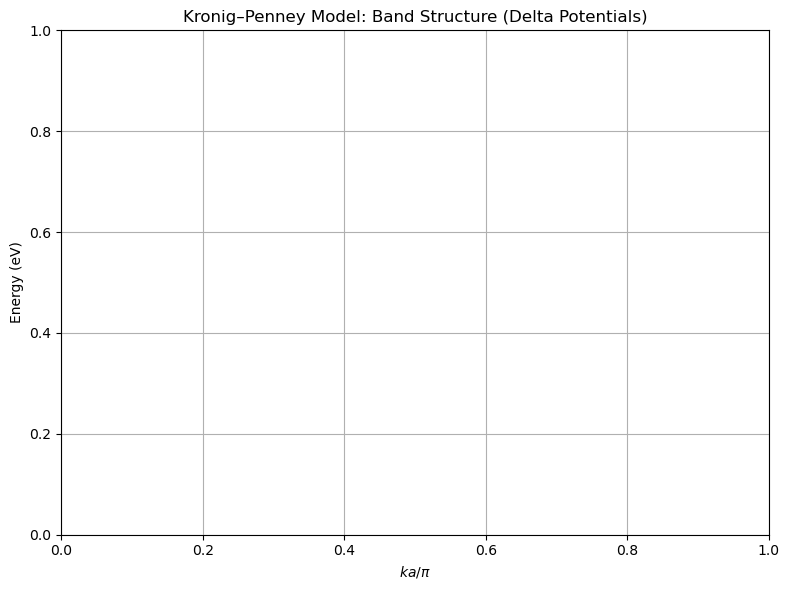

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
hbar = 1.0545718e-34   # J·s
m = 9.10938356e-31     # kg
eV = 1.60218e-19       # J

# Parameters
a = 5e-10              # lattice constant [m]
V0 = 10 * eV           # potential strength [J]
k_vals = np.linspace(-np.pi / a, np.pi / a, 400)  # k-space points
E_vals = np.linspace(0.01 * eV, 50 * eV, 1500)    # energy range [J]

# Meshgrid
K, E = np.meshgrid(k_vals, E_vals)
q = np.sqrt(2 * m * E) / hbar
lhs = np.cos(K * a)
rhs = np.cos(q * a) + (m * V0 / (hbar**2 * q)) * np.sin(q * a)

# Find where the condition is satisfied: |lhs - rhs| <= tolerance
condition = np.abs(lhs - rhs) < 0.05  # adjustable tolerance

# Plot
plt.figure(figsize=(8, 6))
for i, k in enumerate(k_vals):
    energies = E_vals[condition[:, i]] / eV
    if len(energies):
        plt.plot([k * a / np.pi] * len(energies), energies, 'b.', markersize=1)

plt.title("Kronig–Penney Model: Band Structure (Delta Potentials)")
plt.xlabel(r"$k a / \pi$")
plt.ylabel("Energy (eV)")
plt.grid(True)
plt.tight_layout()
plt.show()
